In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.utils import resample

print("All imports successful!")

#Deep wide and deep narrow
#Predicting CHF 

All imports successful!


In [62]:
df = pd.read_csv("https://raw.githubusercontent.com/The1OGShaggy/pyMAISE_VarianceReductionBiasMitigationFinal/refs/heads/main/chf_combined.csv")
df_lhs = pd.read_csv("https://raw.githubusercontent.com/The1OGShaggy/pyMAISE_VarianceReductionBiasMitigationFinal/refs/heads/main/lhs_samples.csv")
df_multi_stratified = pd.read_csv("https://raw.githubusercontent.com/The1OGShaggy/pyMAISE_VarianceReductionBiasMitigationFinal/refs/heads/main/multi_stratified_samples.csv")
df_random_samples = pd.read_csv("https://raw.githubusercontent.com/The1OGShaggy/pyMAISE_VarianceReductionBiasMitigationFinal/refs/heads/main/random_samples.csv")

#check that all datasets loaded properly
print("Combined dataset shape:", df.shape)
print("LHS samples shape:", df_lhs.shape)
print("Multi-stratified samples shape:", df_multi_stratified.shape)
print("Random samples shape:", df_random_samples.shape)
print("All datasets loaded successfully!")

Combined dataset shape: (2500, 7)
LHS samples shape: (1000, 7)
Multi-stratified samples shape: (1267, 7)
Random samples shape: (1000, 7)
All datasets loaded successfully!


In [63]:
#Get Target 
target = "CHF (kW m-2)"
features = [col for col in df.columns if col != target]

In [64]:
#Train Test Split
X = df[features]
y = df[target]
#80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#Latin Hypercube
X_lhs = df_lhs[features]
y_lhs = df_lhs[target]
#80/20
X_train_lhs, X_test_lhs, y_train_lhs, y_test_lhs = train_test_split(
    X_lhs, y_lhs, test_size=0.2, random_state=42
)
#Stratified Sampling
X_str = df_multi_stratified[features]
y_str = df_multi_stratified[target]

X_train_multi_stratified, X_test_multi_stratified, y_train_multi_stratified, y_test_multi_stratified = train_test_split(
    X_str, y_str, test_size=0.2, random_state=42
)

print("Train Test Split Finished")

#Bootstrapping
X_train_boot, y_train_boot = resample(
    X_train, y_train,
    replace=True,
    n_samples=len(X_train),
    random_state=42
)

X_train_lhs_boot, y_train_lhs_boot = resample(
    X_train_lhs, y_train_lhs,
    replace=True,
    n_samples=len(X_train_lhs),
    random_state=42
)

X_train_multi_boot, y_train_multi_boot = resample(
    X_train_multi_stratified, y_train_multi_stratified,
    replace=True,
    n_samples=len(X_train_multi_stratified),
    random_state=42
)


Train Test Split Finished


In [73]:
#Preproccessing and Model Pipeline
numeric_features = features

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)
#Basic Model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Wide and Deep Model
model_wide = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(256, 128, 64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Narrow and Shallow
model_shallow = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(16,),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])
#Boot strapped
model_boot = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Wide and Deep Boot Model
model_wide_boot = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(256, 128, 64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Narrow and Shallow
model_shallow_boot = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(16,),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Train Basic Model
model.fit(X_train, y_train)
model.fit(X_train_lhs, y_train_lhs)
model.fit(X_train_multi_stratified, y_train_multi_stratified)
#Train Wide Model
model_wide.fit(X_train, y_train)
model_wide.fit(X_train_lhs, y_train_lhs)
model_wide.fit(X_train_multi_stratified, y_train_multi_stratified)
#Train Shallow Model
model_shallow.fit(X_train, y_train)
model_shallow.fit(X_train_lhs, y_train_lhs)
model_shallow.fit(X_train_multi_stratified, y_train_multi_stratified)
#BootStrapping
model_boot.fit(X_train_boot, y_train_boot)
model_boot.fit(X_train_lhs_boot, y_train_lhs_boot)
model_boot.fit(X_train_multi_boot, y_train_multi_boot)

model_wide_boot.fit(X_train_boot, y_train_boot)
model_wide_boot.fit(X_train_lhs_boot, y_train_lhs_boot)
model_wide_boot.fit(X_train_multi_boot, y_train_multi_boot)

model_shallow_boot.fit(X_train_boot, y_train_boot)
model_shallow_boot.fit(X_train_lhs_boot, y_train_lhs_boot)
model_shallow_boot.fit(X_train_multi_boot, y_train_multi_boot)
print("All Models Trained!")

C:\Users\zachs\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\zachs\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\zachs\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\zachs\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\zachs\anaconda3\Lib\site-packages\sklearn\neural_network\_m

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('nn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse mat


Neural Network Regression Results
---------------------------------
MSE : 382384.7300237739
RMSE: 618.3726465682113
MAE : 391.22179918921705
R^2 : 0.8394810297655115


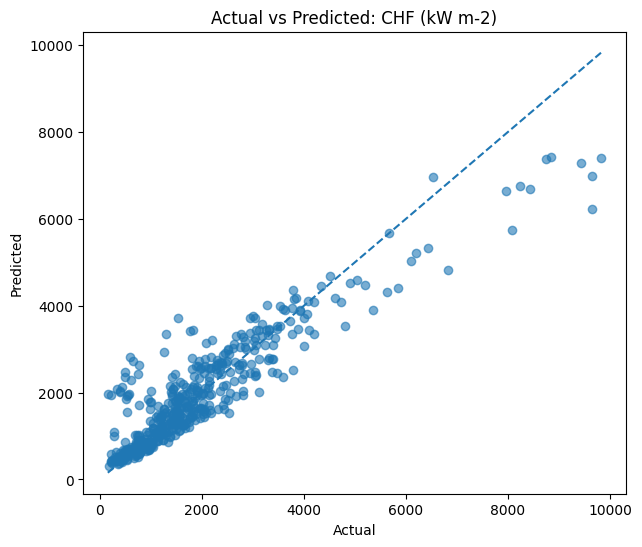

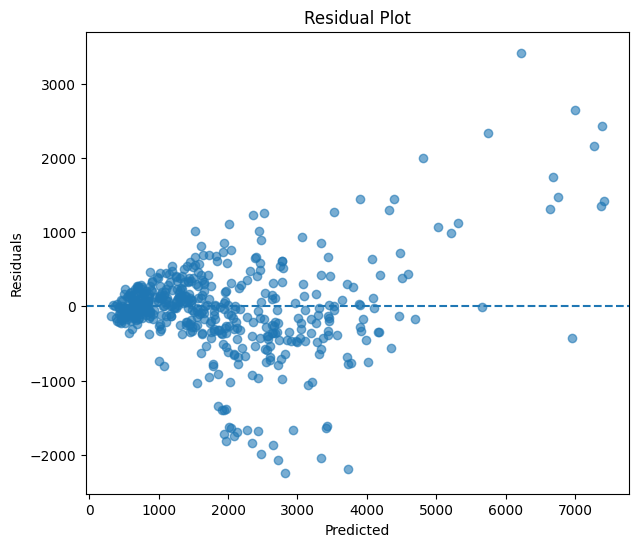

In [75]:
#Pred
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nNeural Network Regression Results")
print("---------------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)

#Plot actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted: {target}")

#Ideal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

#Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


Wide Neural Network Regression Results
---------------------------------
MSE : 82365.10031266343
RMSE: 286.99320603920825
MAE : 164.9068600537059
R^2 : 0.9654244533126961


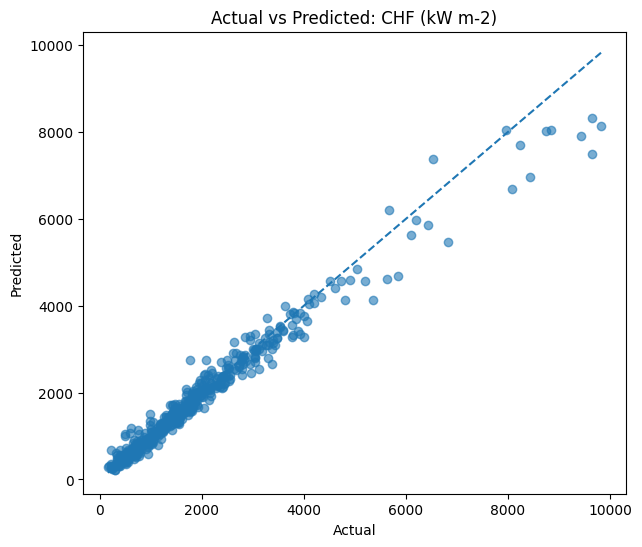

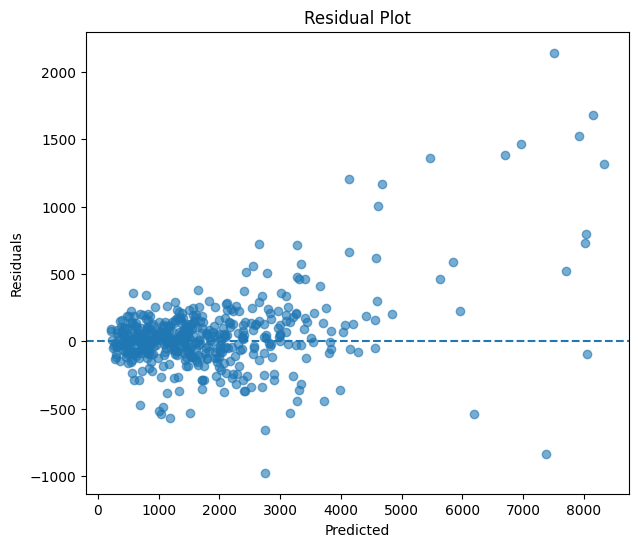

In [77]:
y_pred_wide = model_wide.predict(X_test)

mse = mean_squared_error(y_test, y_pred_wide)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_wide)
r2 = r2_score(y_test, y_pred_wide)

print("\nWide Neural Network Regression Results")
print("---------------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)

#Plot actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_wide, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted: {target}")

#Ideal line
min_val = min(y_test.min(), y_pred_wide.min())
max_val = max(y_test.max(), y_pred_wide.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

#Residual plot
residuals = y_test - y_pred_wide

plt.figure(figsize=(7, 6))
plt.scatter(y_pred_wide, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


Shallow Neural Network Regression Results
---------------------------------
MSE : 1233525.4340424412
RMSE: 1110.6419018038357
MAE : 870.6886908991966
R^2 : 0.4821858278225897


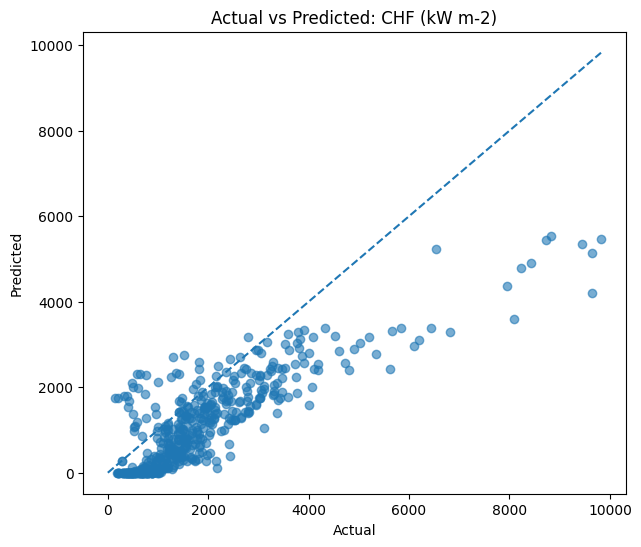

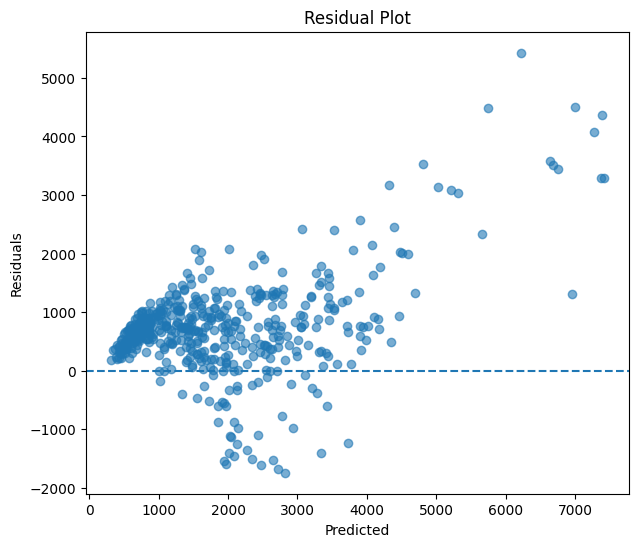

In [79]:
y_pred_shallow = model_shallow.predict(X_test)

mse = mean_squared_error(y_test, y_pred_shallow)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_shallow)
r2 = r2_score(y_test, y_pred_shallow)

print("\nShallow Neural Network Regression Results")
print("---------------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)

#Plot actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_shallow, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted: {target}")

#Ideal line
min_val = min(y_test.min(), y_pred_shallow.min())
max_val = max(y_test.max(), y_pred_shallow.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

#Residual plot
residuals = y_test - y_pred_shallow

plt.figure(figsize=(7, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


Neural Network Regression Results
---------------------------------
MSE : 349919.8546909996
RMSE: 591.5402392830091
MAE : 402.3626496856962
R^2 : 0.8531092631860354


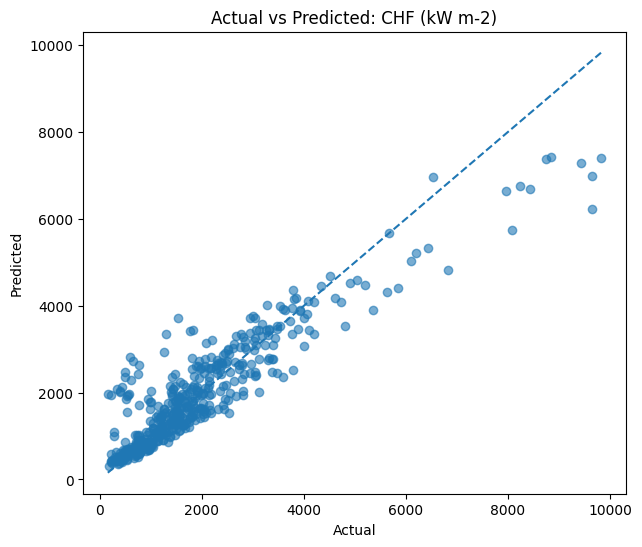

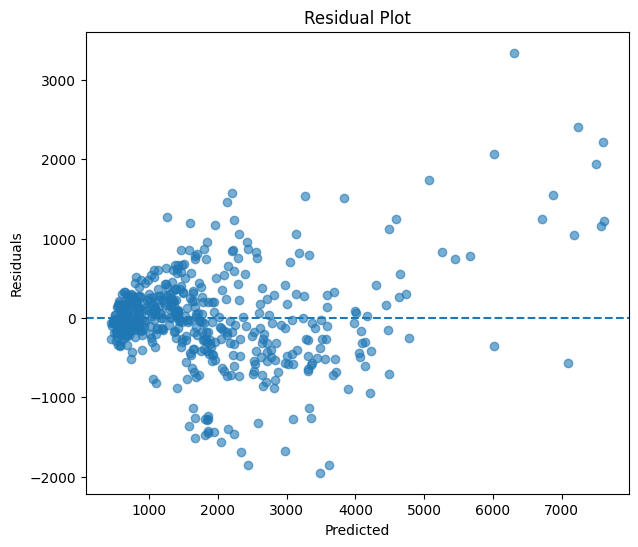

In [81]:
#Pred
y_pred_boot = model_boot.predict(X_test)

mse = mean_squared_error(y_test, y_pred_boot)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_boot)
r2 = r2_score(y_test, y_pred_boot)

print("\nNeural Network Regression Results")
print("---------------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)

#Plot actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted: {target}")

#Ideal line
min_val = min(y_test.min(), y_pred_boot.min())
max_val = max(y_test.max(), y_pred_boot.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

#Residual plot
residuals = y_test - y_pred_boot

plt.figure(figsize=(7, 6))
plt.scatter(y_pred_boot, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


Neural Network Regression Results
---------------------------------
MSE : 54408.10419188934
RMSE: 233.25544836485457
MAE : 141.59188236476797
R^2 : 0.9771603514168836


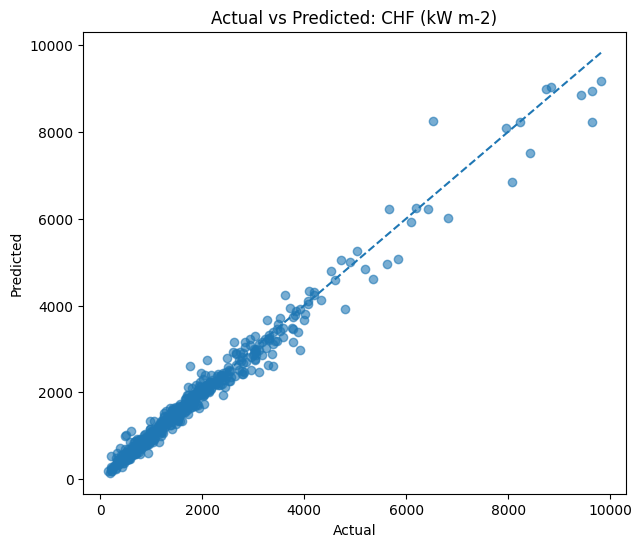

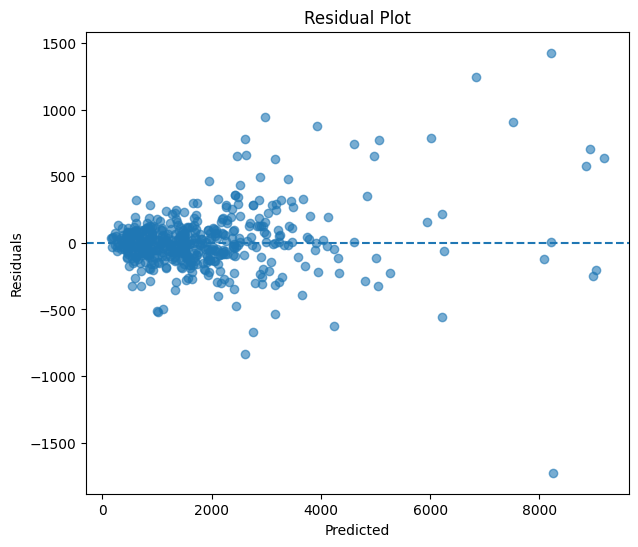

In [83]:
#Pred
y_pred_wide_boot = model_wide_boot.predict(X_test)

mse = mean_squared_error(y_test, y_pred_wide_boot)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_wide_boot)
r2 = r2_score(y_test, y_pred_wide_boot)

print("\nNeural Network Regression Results")
print("---------------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)

#Plot actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_wide_boot, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted: {target}")

#Ideal line
min_val = min(y_test.min(), y_pred_wide_boot.min())
max_val = max(y_test.max(), y_pred_wide_boot.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

#Residual plot
residuals = y_test - y_pred_wide_boot

plt.figure(figsize=(7, 6))
plt.scatter(y_pred_wide_boot, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


Neural Network Regression Results
---------------------------------
MSE : 1134998.1369245434
RMSE: 1065.3629132481303
MAE : 836.6023509139604
R^2 : 0.523546005234405


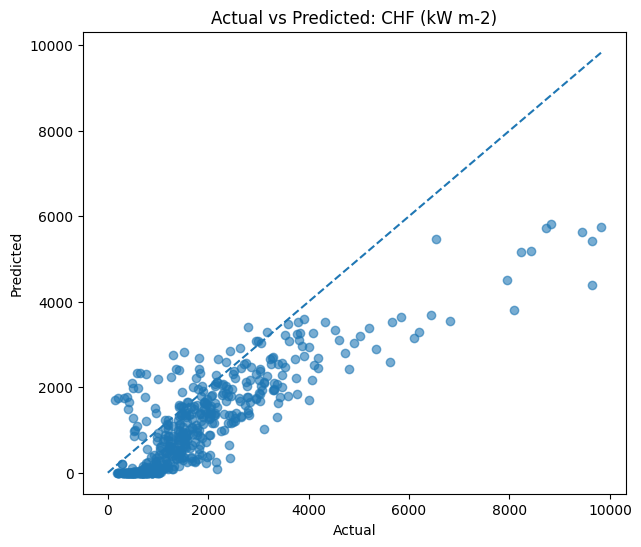

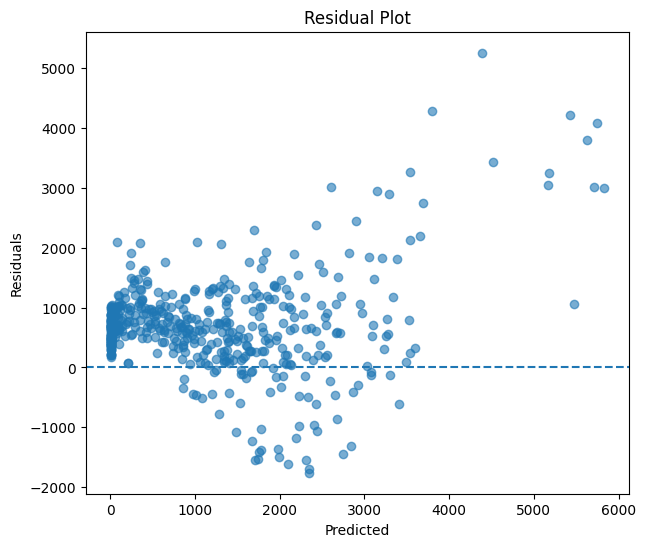

In [87]:
#Pred
y_pred_shall_boot = model_shallow_boot.predict(X_test)

mse = mean_squared_error(y_test, y_pred_shall_boot)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_shall_boot)
r2 = r2_score(y_test, y_pred_shall_boot)

print("\nNeural Network Regression Results")
print("---------------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)

#Plot actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_shall_boot, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted: {target}")

#Ideal line
min_val = min(y_test.min(), y_pred_shall_boot.min())
max_val = max(y_test.max(), y_pred_shall_boot.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

#Residual plot
residuals = y_test - y_pred_shall_boot

plt.figure(figsize=(7, 6))
plt.scatter(y_pred_shall_boot, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()